In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Semilla para que te dé los mismos datos que a mí
np.random.seed(42)

# 500 ventas normales
horas_trabajadas = np.random.uniform(1, 10, 490)
ventas = horas_trabajadas * 150 + np.random.normal(0, 100, 490) # 150$ por hora aprox

# 10 ventas ANÓMALAS (posibles fraudes/errores de digitación)
horas_anomalas = np.array([2, 3, 2.5, 9, 8, 1, 9.5, 3, 8.5, 2])
ventas_anomalas = np.array([5000, 4800, 5200, 200, 150, 4500, 100, 4900, 50, 5100])

# Unimos todo
horas = np.concatenate([horas_trabajadas, horas_anomalas])
ventas_totales = np.concatenate([ventas, ventas_anomalas])

# Creamos el DataFrame (como en la empresa)
df = pd.DataFrame({'Horas_Trabajadas': horas, 'Ventas_$': ventas_totales})

print("Base de datos de ventas creada:")
print(df.tail(15)) # Muestra las últimas 15 donde están las anomalías
print(f"\nTotal registros: {len(df)}")

Base de datos de ventas creada:
     Horas_Trabajadas     Ventas_$
485          9.110422  1546.151081
486          1.409017   150.073744
487          3.528669   490.530150
488          9.553703  1461.642043
489          9.012374  1385.301787
490          2.000000  5000.000000
491          3.000000  4800.000000
492          2.500000  5200.000000
493          9.000000   200.000000
494          8.000000   150.000000
495          1.000000  4500.000000
496          9.500000   100.000000
497          3.000000  4900.000000
498          8.500000    50.000000
499          2.000000  5100.000000

Total registros: 500


In [2]:
plt.figure(figsize=(10,6))

# Ventas normales en azul
normales = df[df['Es_Anomalia'] == False]
anomalias = df[df['Es_Anomalia'] == True]

plt.scatter(normales['Horas_Trabajadas'], normales['Ventas_$'], label='Ventas Normales', alpha=0.6)
plt.scatter(anomalias['Horas_Trabajadas'], anomalias['Ventas_$'], color='red', s=100, label='FRAUDE / ERROR DETECTADO', edgecolors='black')

# Línea de lo que debería ser
plt.plot(df['Horas_Trabajadas'].sort_values(), modelo.predict(df[['Horas_Trabajadas']].sort_values()), color='green', linewidth=2, label='Venta Esperada por la IA')

plt.title('Proyecto: Detección de Anomalías en Ventas - Juan Carlos')
plt.xlabel('Horas Trabajadas')
plt.ylabel('Ventas en $')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Resumen: {len(anomalias)} posibles fraudes/errores detectados de {len(df)} ventas.")

KeyError: 'Es_Anomalia'

<Figure size 1000x600 with 0 Axes>

Fraudes detectados: 8
     Horas_Trabajadas  Ventas_$  Venta_Esperada        Error  Es_Anomalia
490               2.0    5000.0      452.832982  4547.167018         True
491               3.0    4800.0      571.534240  4228.465760         True
492               2.5    5200.0      512.183611  4687.816389         True
495               1.0    4500.0      334.131724  4165.868276         True
496               9.5     100.0     1343.092418  1243.092418         True
497               3.0    4900.0      571.534240  4328.465760         True
498               8.5      50.0     1224.391160  1174.391160         True
499               2.0    5100.0      452.832982  4647.167018         True


TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

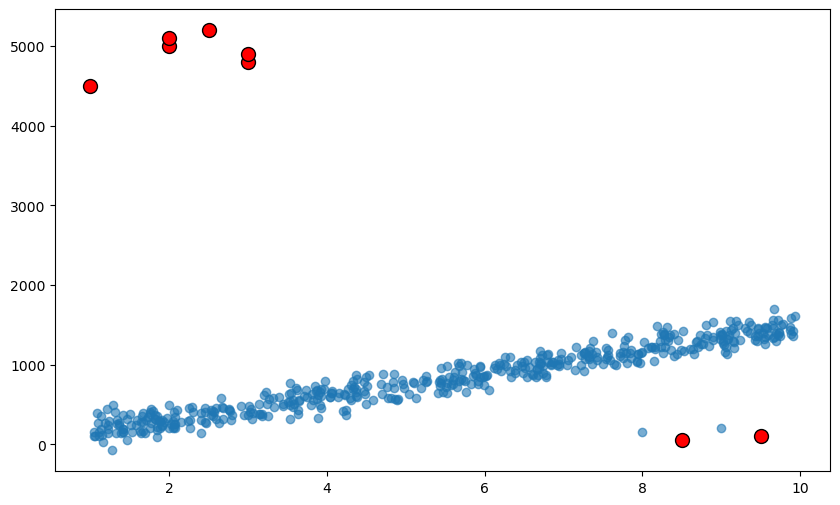

In [3]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X = df[['Horas_Trabajadas']]
y = df['Ventas_$']

modelo = LinearRegression()
modelo.fit(X, y)

df['Venta_Esperada'] = modelo.predict(X)
df['Error'] = abs(df['Ventas_$'] - df['Venta_Esperada'])
limite_fraude = df['Error'].mean() + 2 * df['Error'].std()
df['Es_Anomalia'] = df['Error'] > limite_fraude

print(f"Fraudes detectados: {df['Es_Anomalia'].sum()}")
print(df[df['Es_Anomalia'] == True])

# --- GRÁFICA ---
plt.figure(figsize=(10,6))
normales = df[df['Es_Anomalia'] == False]
anomalias = df[df['Es_Anomalia'] == True]

plt.scatter(normales['Horas_Trabajadas'], normales['Ventas_$'], label='Ventas Normales', alpha=0.6)
plt.scatter(anomalias['Horas_Trabajadas'], anomalias['Ventas_$'], color='red', s=100, label='FRAUDE / ERROR', edgecolors='black')
plt.plot(df['Horas_Trabajadas'].sort_values(), modelo.predict(df[['Horas_Trabajadas']].sort_values().to_frame()), color='green', linewidth=2, label='Venta Esperada')

plt.title('Proyecto: Detección de Anomalías en Ventas - Juan Carlos')
plt.xlabel('Horas Trabajadas')
plt.ylabel('Ventas en $')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

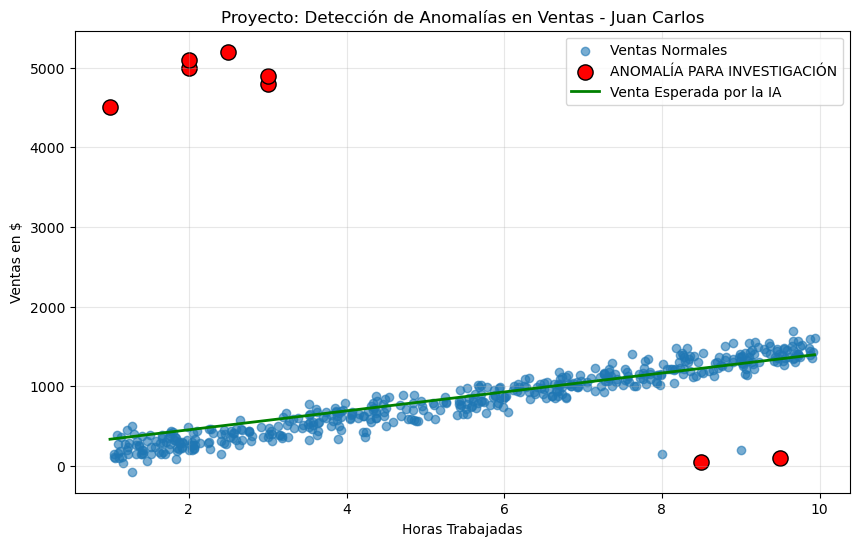

¡Archivo guardado! ventas_con_anomalias.csv listo para GitHub


In [4]:
# Gráfica corregida y PRO para GitHub
plt.figure(figsize=(10,6))

normales = df[df['Es_Anomalia'] == False]
anomalias = df[df['Es_Anomalia'] == True]

plt.scatter(normales['Horas_Trabajadas'], normales['Ventas_$'], label='Ventas Normales', alpha=0.6)
plt.scatter(anomalias['Horas_Trabajadas'], anomalias['Ventas_$'], color='red', s=120, label='ANOMALÍA PARA INVESTIGACIÓN', edgecolors='black')

# Línea verde corregida
horas_ordenadas = df['Horas_Trabajadas'].sort_values()
plt.plot(horas_ordenadas, modelo.predict(horas_ordenadas.to_frame()), color='green', linewidth=2, label='Venta Esperada por la IA')

plt.title('Proyecto: Detección de Anomalías en Ventas - Juan Carlos')
plt.xlabel('Horas Trabajadas')
plt.ylabel('Ventas en $')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Guardamos el CSV que es lo que va a GitHub
df.to_csv('ventas_con_anomalias.csv', index=False)
print("¡Archivo guardado! ventas_con_anomalias.csv listo para GitHub")

In [1]:
import os
print(os.getcwd())


C:\Users\juan carlos
